# Segurança Pública no Rio de Janeiro: Melhora Real ou Migração Criminal?

## Pergunta de pesquisa
A queda nos crimes violentos no Rio de Janeiro entre 2018 e 2023 reflete uma melhora real de segurança pública, uma migração da atividade criminosa para modalidades menos violentas, ou uma combinação dos dois fatores?

## Contexto
A cobertura da grande mídia e o discurso político costumam olhar apenas para os números brutos de crimes violentos, associando sua queda exclusivamente a políticas de segurança pública. Essa leitura, no entanto, pode ignorar um fenômeno mais complexo: a criminalidade não necessariamente desaparece, ela pode estar se reorganizando em modalidades menos violentas e mais difíceis de perceber no debate público.

## Metodologia

**Fonte de dados:** Base de evolução mensal de ocorrências por CISP (Circunscrição Integrada de Segurança Pública), disponibilizada pelo ISP-RJ (Instituto de Segurança Pública do Rio de Janeiro), cobrindo o período de 2003 a 2024.

**Classificação dos crimes:** Para investigar a hipótese de migração criminal, os tipos de ocorrência foram agrupados em duas categorias:
- **Crimes violentos:** letalidade violenta, lesão corporal dolosa, estupro, total de roubos, sequestro, extorsão e sequestro relâmpago.
- **Crimes não-violentos:** total de furtos e estelionato.

**Tratamento de dados:** O ano de 2024 foi excluído da análise principal por estar incompleto na base (dados disponíveis apenas até julho), o que distorceria a comparação com anos completos.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('03.BaseDPEvolucaoMensalCisp.csv', sep=';', encoding='latin1')
df.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3


In [3]:
print (df.columns.tolist())

['cisp', 'mes', 'ano', 'mes_ano', 'aisp', 'risp', 'munic', 'mcirc', 'regiao', 'hom_doloso', 'lesao_corp_morte', 'latrocinio', 'cvli', 'hom_por_interv_policial', 'letalidade_violenta', 'tentat_hom', 'lesao_corp_dolosa', 'estupro', 'hom_culposo', 'lesao_corp_culposa', 'roubo_transeunte', 'roubo_celular', 'roubo_em_coletivo', 'roubo_rua', 'roubo_veiculo', 'roubo_carga', 'roubo_comercio', 'roubo_residencia', 'roubo_banco', 'roubo_cx_eletronico', 'roubo_conducao_saque', 'roubo_apos_saque', 'roubo_bicicleta', 'outros_roubos', 'total_roubos', 'furto_veiculos', 'furto_transeunte', 'furto_coletivo', 'furto_celular', 'furto_bicicleta', 'outros_furtos', 'total_furtos', 'sequestro', 'extorsao', 'sequestro_relampago', 'estelionato', 'apreensao_drogas', 'posse_drogas', 'trafico_drogas', 'apreensao_drogas_sem_autor', 'recuperacao_veiculos', 'apf', 'aaapai', 'cmp', 'cmba', 'ameaca', 'pessoas_desaparecidas', 'encontro_cadaver', 'encontro_ossada', 'pol_militares_mortos_serv', 'pol_civis_mortos_serv', 'r

In [4]:
colunas_violentas = ['letalidade_violenta', 'lesao_corp_dolosa', 'estupro', 'total_roubos', 'sequestro', 'extorsao', 'sequestro_relampago']
colunas_nao_violentas = ['total_furtos', 'estelionato']

df_ano = df.groupby('ano')[colunas_violentas + colunas_nao_violentas].sum().reset_index()
df_ano['total_violentos'] = df_ano[colunas_violentas].sum(axis=1)
df_ano['total_nao_violentos'] = df_ano[colunas_nao_violentas].sum(axis=1)

df_ano[['ano', 'total_violentos', 'total_nao_violentos']]

,ano,total_violentos,total_nao_violentos
0,2003,208445,130248
1,2004,197678,131354
2,2005,205278,142219
3,2006,212426,159168
4,2007,223440,179648
5,2008,227403,192630
6,2009,230061,192264
7,2010,213297,198829
8,2011,203314,205246
9,2012,205951,212302


## Achados

### 1. Evolução geral: violentos vs. não-violentos (2003-2023)

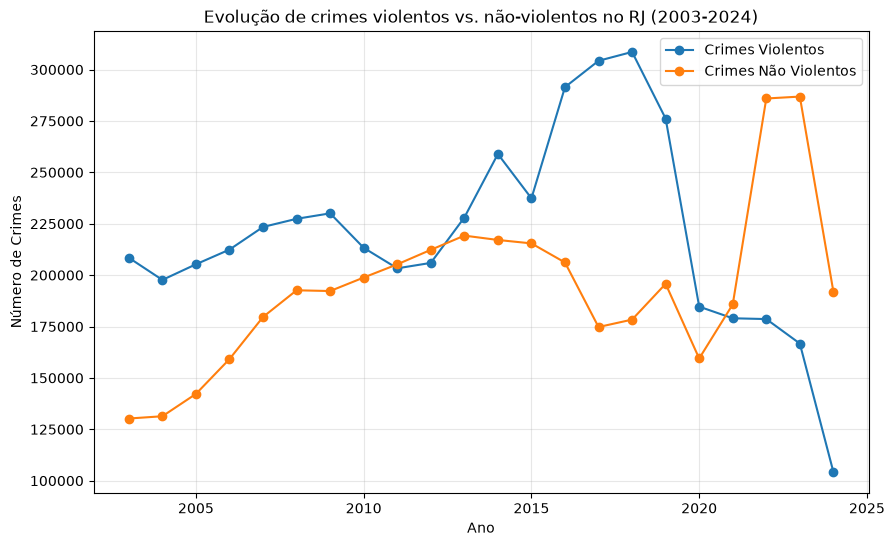

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df_ano['ano'], df_ano['total_violentos'], marker='o', label='Crimes Violentos')
plt.plot(df_ano['ano'], df_ano['total_nao_violentos'], marker='o', label='Crimes Não Violentos')
plt.title('Evolução de crimes violentos vs. não-violentos no RJ (2003-2024)')
plt.xlabel('Ano')
plt.ylabel('Número de Crimes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [6]:
df[df['ano'] == 2024]['mes'].unique()

array([1, 2, 3, 4, 5, 6, 7])

In [7]:
df_ano_plot = df_ano[df_ano['ano'] < 2024]

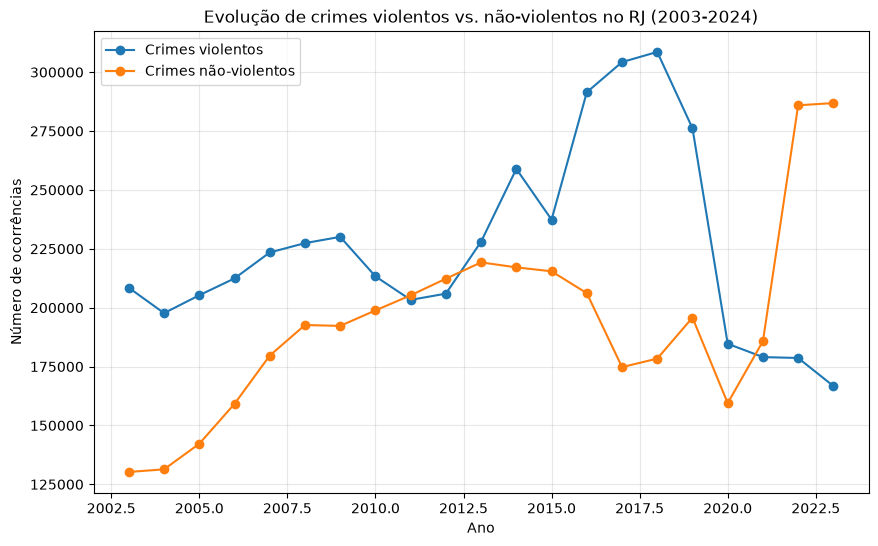

In [8]:
plt.figure(figsize=(10,6))
plt.plot(df_ano_plot['ano'], df_ano_plot['total_violentos'], marker='o', label='Crimes violentos')
plt.plot(df_ano_plot['ano'], df_ano_plot['total_nao_violentos'], marker='o', label='Crimes não-violentos')
plt.title('Evolução de crimes violentos vs. não-violentos no RJ (2003-2024)')
plt.xlabel('Ano')
plt.ylabel('Número de ocorrências')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

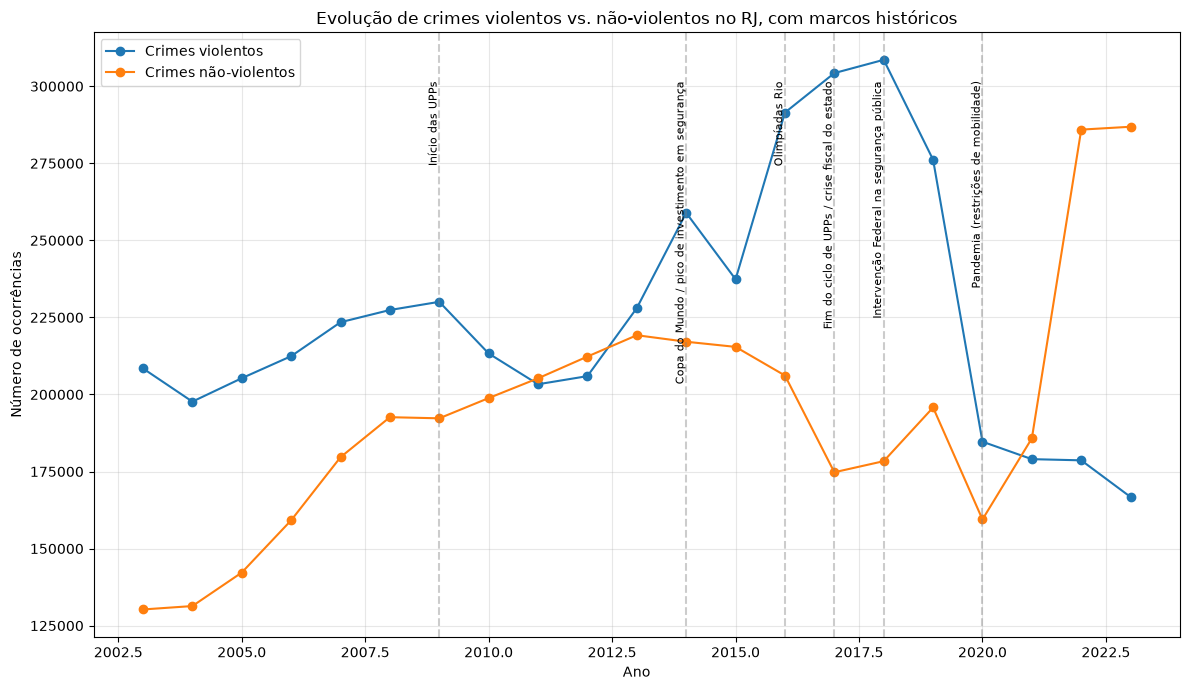

In [9]:
eventos = {
    2009: 'Início das UPPs',
    2014: 'Copa do Mundo / pico de investimento em segurança',
    2016: 'Olimpíadas Rio',
    2017: 'Fim do ciclo de UPPs / crise fiscal do estado',
    2018: 'Intervenção Federal na segurança pública',
    2020: 'Pandemia (restrições de mobilidade)',
}

plt.figure(figsize=(12,7))
plt.plot(df_ano_plot['ano'], df_ano_plot['total_violentos'], marker='o', label='Crimes violentos', color='tab:blue')
plt.plot(df_ano_plot['ano'], df_ano_plot['total_nao_violentos'], marker='o', label='Crimes não-violentos', color='tab:orange')

for ano, evento in eventos.items():
    plt.axvline(x=ano, color='gray', linestyle='--', alpha=0.4)
    plt.text(ano, plt.ylim()[1]*0.95, evento, rotation=90, fontsize=8, ha='right', va='top')

plt.title('Evolução de crimes violentos vs. não-violentos no RJ, com marcos históricos')
plt.xlabel('Ano')
plt.ylabel('Número de ocorrências')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Entre 2003 e 2018, os crimes violentos apresentam tendência de alta, com pico coincidindo com a Intervenção Federal de 2018. A partir de 2019, há uma queda acentuada, que se mantém até 2023. No entanto, essa queda não é acompanhada por uma redução equivalente nos crimes não-violentos: pelo contrário, a partir de 2022 observa-se uma inversão clara, com os crimes não-violentos ultrapassando os violentos pela primeira vez na série histórica.

*Nota: o ano de 2024 foi omitido dos gráficos e tabelas por estar incompleto na base (dados até julho), conforme detalhado na Metodologia.*

### 2. A divergência regional confirma um padrão estadual

In [10]:
periodo_antes = df[df['ano'].between(2015, 2017)]
periodo_depois = df[df['ano'].between(2021, 2023)]

regional_antes = periodo_antes.groupby('regiao')[colunas_violentas + colunas_nao_violentas].sum()
regional_antes['total_violentos'] = regional_antes[colunas_violentas].sum(axis=1)
regional_antes['total_nao_violentos'] = regional_antes[colunas_nao_violentas].sum(axis=1)

regional_depois = periodo_depois.groupby('regiao')[colunas_violentas + colunas_nao_violentas].sum()
regional_depois['total_violentos'] = regional_depois[colunas_violentas].sum(axis=1)
regional_depois['total_nao_violentos'] = regional_depois[colunas_nao_violentas].sum(axis=1)

comparacao = pd.DataFrame({
    'violentos_2015_17': regional_antes['total_violentos'],
    'violentos_2021_23': regional_depois['total_violentos'],
    'nao_violentos_2015_17': regional_antes['total_nao_violentos'],
    'nao_violentos_2021_23': regional_depois['total_nao_violentos'],
})

comparacao['var_violentos_%'] = ((comparacao['violentos_2021_23'] / comparacao['violentos_2015_17']) - 1) * 100
comparacao['var_nao_violentos_%'] = ((comparacao['nao_violentos_2021_23'] / comparacao['nao_violentos_2015_17']) - 1) * 100

comparacao.sort_values('var_nao_violentos_%', ascending=False)

,violentos_2015_17,violentos_2021_23,nao_violentos_2015_17,nao_violentos_2021_23,var_violentos_%,var_nao_violentos_%
regiao,,,,,,
Capital,402194,257497,341201,446933,-35.976917,30.988186
Interior,110616,81186,115808,142219,-26.605554,22.805851
Grande Niterói,102318,45688,53752,65762,-55.347055,22.343355
Baixada Fluminense,217977,140000,85591,103644,-35.773040,21.092171


A comparação entre os períodos 2015-2017 e 2021-2023 mostra que a queda em crimes violentos e o aumento em crimes não-violentos ocorrem em todas as regiões do estado, não apenas na Capital. Isso sugere que o fenômeno não é um efeito isolado de uma política local, mas uma tendência estrutural.

## Discussão

Os achados sugerem que a queda nos crimes violentos observada a partir de 2019 não representa, isoladamente, uma melhora geral de segurança pública. A inversão de padrão a partir de 2022, em que crimes não-violentos passam a superar os violentos, e o fato de esse padrão se repetir em todas as regiões do estado, são mais consistentes com a hipótese de migração de modalidade criminal do que com uma explicação única baseada em política pública.

Isso não significa que políticas de segurança não tiveram efeito algum. A intervenção federal de 2018 e o fim do ciclo de UPPs coincidem com pontos de inflexão visíveis na série histórica, o que sugere que fatores institucionais também influenciaram a trajetória dos crimes violentos. O mais provável é que os dois fatores atuem em conjunto: uma redução real de violência armada e organizada, acompanhada de uma reorganização da atividade criminosa para formas menos violentas e de maior escala, como furto e estelionato.


## Limitações

Esta análise possui limitações importantes que devem ser consideradas na interpretação dos resultados:

- **Subnotificação:** nem toda ocorrência é registrada, e a taxa de subnotificação pode variar por tipo de crime e ao longo do tempo, o que dificulta comparações diretas entre categorias.
- **Mudanças metodológicas:** alterações na forma de classificação ou registro de ocorrências ao longo de duas décadas podem afetar a comparabilidade da série histórica.
- **Correlação não implica causalidade:** a coincidência temporal entre marcos históricos (UPPs, intervenção federal, pandemia) e mudanças nos indicadores não comprova relação causal direta.
- **Fatores externos não capturados:** variáveis como mudanças econômicas, demográficas ou tecnológicas (ex: pagamentos digitais reduzindo assaltos a banco, mas facilitando golpes online) não foram incluídas na análise e podem explicar parte da variação observada.

## Conclusão

A queda nos crimes violentos no Rio de Janeiro entre 2018 e 2023 não pode ser atribuída exclusivamente a políticas de segurança pública. Os dados indicam um cenário mais complexo, em que a redução da violência armada coincide com um crescimento expressivo de crimes não-violentos, padrão observado de forma consistente em todas as regiões do estado. Essa evidência reforça a importância de olhar além dos números brutos de criminalidade violenta ao avaliar a eficácia de políticas de segurança, já que uma leitura simplificada pode mascarar a persistência, e possivelmente o crescimento, da atividade criminosa sob novas formas.